Загрузка данных...
Обучающих примеров: (400, 3000), тестовых примеров: (320, 3000)
Генерация скалограмм для обучающей выборки...


c:\Users\GH\AppData\Local\Programs\Python\Python311\Lib\site-packages\pywt\_cwt.py:113: FutureWarning: Wavelets from the family cmor, without parameters specified in the name are deprecated. The name should follow the format cmorB-C, where B and C are floats representing the bandwidth frequency and center frequency, respectively (example, for backward compatibility: cmor = cmor1.0-0.5).
  wavelet = DiscreteContinuousWavelet(wavelet)


Генерация скалограмм для тестовой выборки...
Размерность обучающих изображений: (400, 32, 3000, 1)
Размерность тестовых изображений: (320, 32, 3000, 1)


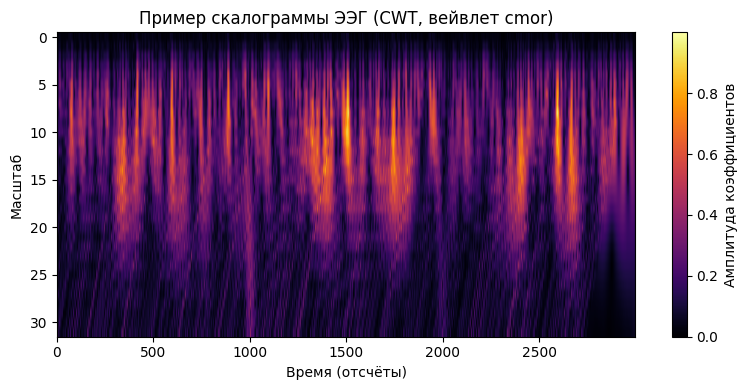

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 3000, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 1500, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 1500, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 1500, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 750, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 750, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 384000)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    49,152,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 49,171,073 (187.57 MB)

 Trainable params: 49,171,073 (187.57 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 9s 633ms/step - accuracy: 0.4850 - loss: 2.7432 - val_accuracy: 0.5906 - val_loss: 0.6929
Epoch 2/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 13s 1s/step - accuracy: 0.5550 - loss: 0.6911 - val_accuracy: 0.5000 - val_loss: 0.6932
Epoch 3/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 16s 663ms/step - accuracy: 0.5025 - loss: 0.6931 - val_accuracy: 0.5000 - val_loss: 0.6932
Epoch 4/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 8s 643ms/step - accuracy: 0.5025 - loss: 0.6924 - val_accuracy: 0.5000 - val_loss: 0.6924
Epoch 5/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 8s 653ms/step - accuracy: 0.5450 - loss: 0.6873 - val_accuracy: 0.7031 - val_loss: 0.6847
Epoch 6/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 8s 653ms/step - accuracy: 0.6025 - loss: 0.6660 - val_accuracy: 0.7188 - val_loss: 0.6566
Epoch 7/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 8s 628ms/step - accuracy: 0.5925 - loss: 0.6674 - val_accuracy: 0.6000 - val_loss: 0.6649
Epoch 8/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 8s 628ms/step - accuracy: 0.6200 - loss: 0.6671 - val_accuracy: 0.7

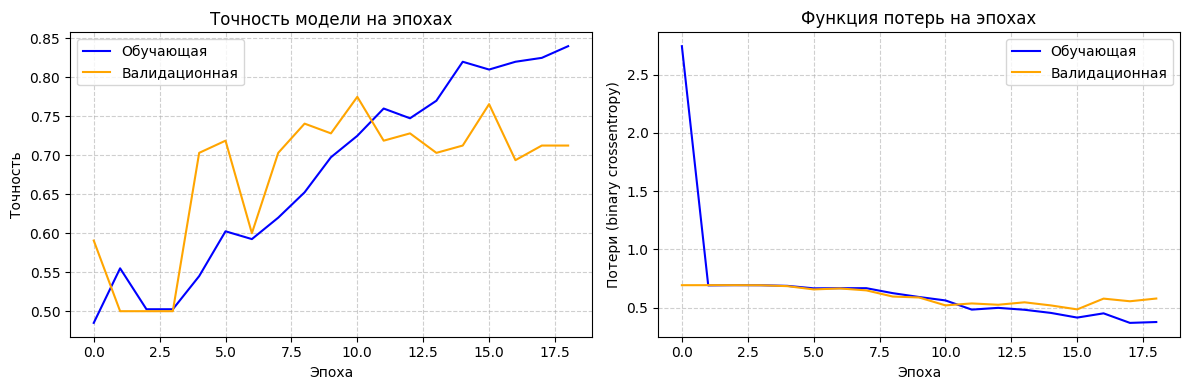

Модель сохранена как eeg_motor_imagery_cnn.h5


In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pywt
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping

# ------------------------------------------------------------
# 1. Загрузка данных (пути к файлам)
# ------------------------------------------------------------
data_dir = r"D:\MASTER\Term4\2\Seminar_GHADEER\lab05"

# Обучающая выборка: сигналы и метки
X_train_path = os.path.join(data_dir, "MI-EEG-B9T.csv")
y_train_path = os.path.join(data_dir, "2class_MI_EEG_train_9.csv")

# Тестовая выборка: сигналы и метки
X_test_path = os.path.join(data_dir, "MI-EEG-B9E.csv")
y_test_path = os.path.join(data_dir, "2class_MI_EEG_test_9.csv")

print("Загрузка данных...")
X_train_raw = pd.read_csv(X_train_path, header=None).values
y_train = pd.read_csv(y_train_path, header=None).values.ravel().astype(np.float32)
X_test_raw = pd.read_csv(X_test_path, header=None).values
y_test = pd.read_csv(y_test_path, header=None).values.ravel().astype(np.float32)

# Стандартизация по каждому сигналу (убираем смещение и масштабируем)
scaler = StandardScaler()
X_train_norm = scaler.fit_transform(X_train_raw)
X_test_norm = scaler.transform(X_test_raw)

print(f"Обучающих примеров: {X_train_norm.shape}, тестовых примеров: {X_test_norm.shape}")

# ------------------------------------------------------------
# 2. Вейвлет-преобразование -> скалограммы (изображения)
# ------------------------------------------------------------
def build_scalograms(data, scales=np.arange(1, 33), wavelet='cmor'):
    """
    Преобразует сигналы ЭЭГ в скалограммы (2D-изображения) с помощью CWT.
    Возвращает массив (N, len(scales), длина_сигнала, 1)
    """
    images = []
    for row in data:
        coeffs, _ = pywt.cwt(row, scales, wavelet)
        # Модуль коэффициентов
        img = np.abs(coeffs)
        # Нормализация по каждому изображению в диапазон [0,1]
        img = (img - img.min()) / (img.max() - img.min() + 1e-8)
        images.append(img)
    return np.array(images)[..., np.newaxis]   # добавляем канал

print("Генерация скалограмм для обучающей выборки...")
X_train_img = build_scalograms(X_train_norm)
print("Генерация скалограмм для тестовой выборки...")
X_test_img = build_scalograms(X_test_norm)
print(f"Размерность обучающих изображений: {X_train_img.shape}")
print(f"Размерность тестовых изображений: {X_test_img.shape}")

# Визуализируем одну скалограмму
plt.figure(figsize=(8, 4))
plt.imshow(X_train_img[0, :, :, 0], aspect='auto', cmap='inferno')
plt.colorbar(label='Амплитуда коэффициентов')
plt.title('Пример скалограммы ЭЭГ (CWT, вейвлет cmor)')
plt.xlabel('Время (отсчёты)')
plt.ylabel('Масштаб')
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 3. Построение свёрточной нейронной сети (CNN)
# ------------------------------------------------------------
def create_cnn(input_shape):
    model = models.Sequential([
        layers.Input(shape=input_shape),
        
        # Первый свёрточный блок
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.3),
        
        # Второй свёрточный блок
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.3),
        
        # Полносвязная часть
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(1, activation='sigmoid')  # бинарная классификация
    ])
    
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model

input_shape = X_train_img.shape[1:]  # (31, 3000, 1)
model = create_cnn(input_shape)
model.summary()

# ------------------------------------------------------------
# 4. Обучение модели с ранней остановкой
# ------------------------------------------------------------
early_stop = EarlyStopping(monitor='val_accuracy', patience=8,
                           restore_best_weights=True, mode='max')

history = model.fit(
    X_train_img, y_train,
    batch_size=32,
    epochs=50,
    validation_data=(X_test_img, y_test),
    callbacks=[early_stop],
    verbose=1
)

# ------------------------------------------------------------
# 5. Оценка и визуализация результатов
# ------------------------------------------------------------
test_loss, test_acc = model.evaluate(X_test_img, y_test, verbose=0)
print(f"\nТочность на тестовой выборке: {test_acc * 100:.2f}%")

# Графики точности и потерь
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Обучающая', color='blue')
plt.plot(history.history['val_accuracy'], label='Валидационная', color='orange')
plt.title('Точность модели на эпохах')
plt.xlabel('Эпоха')
plt.ylabel('Точность')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Обучающая', color='blue')
plt.plot(history.history['val_loss'], label='Валидационная', color='orange')
plt.title('Функция потерь на эпохах')
plt.xlabel('Эпоха')
plt.ylabel('Потери (binary crossentropy)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

# Сохранение модели (опционально)
model.save("eeg_motor_imagery_cnn.h5")
print("Модель сохранена как eeg_motor_imagery_cnn.h5")